In [32]:
from IPython.display import display, Image
import ipywidgets as widgets
import threading

from jetcam.utils import bgr8_to_jpeg

In [33]:
from jetcam.csi_camera import CSICamera

camera = CSICamera(capture_width=1280, capture_height=720, downsample=2, capture_fps=30)

Error generated. /dvs/git/dirty/git-master_linux/multimedia/nvgstreamer/gst-nvarguscamera/gstnvarguscamerasrc.cpp, execute:805 Failed to create CaptureSession
[ WARN:0@1050.627] global cap_gstreamer.cpp:1728 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1
[ WARN:0@1050.657] global cap_gstreamer.cpp:2099 setProperty OpenCV | GStreamer warning: GStreamer: unhandled property
Error generated. /dvs/git/dirty/git-master_linux/multimedia/nvgstreamer/gst-nvarguscamera/gstnvarguscamerasrc.cpp, execute:805 Failed to create CaptureSession


In [20]:
import time
import os
from datetime import datetime

# Stop button
# ================
stopButton = widgets.Checkbox(
    value=False,
    description='Streaming',
    disabled=False,
    indent=False,
)

# Display function
# ================
def view(button):
    frame = camera.read()
    display_handle=display(Image(data=bgr8_to_jpeg(frame)), display_id=True)

    while True:
        if stopButton.value:
            frame = camera.read()
            display_handle.update(Image(data=bgr8_to_jpeg(frame)))
            time.sleep(5)
            # save/home/ircv15/em7/perception/images
            save_dir = '/home/ircv15/em7/perception/images0513two'
            os.makedirs(save_dir, exist_ok=True)
            filename = datetime.now().strftime('%Y%m%d_%H%M%S_%f') + '.jpg'
            filepath = os.path.join(save_dir, filename)
            with open(filepath, 'wb') as f:
                f.write(bgr8_to_jpeg(frame))


Checkbox(value=False, description='Streaming', indent=False)

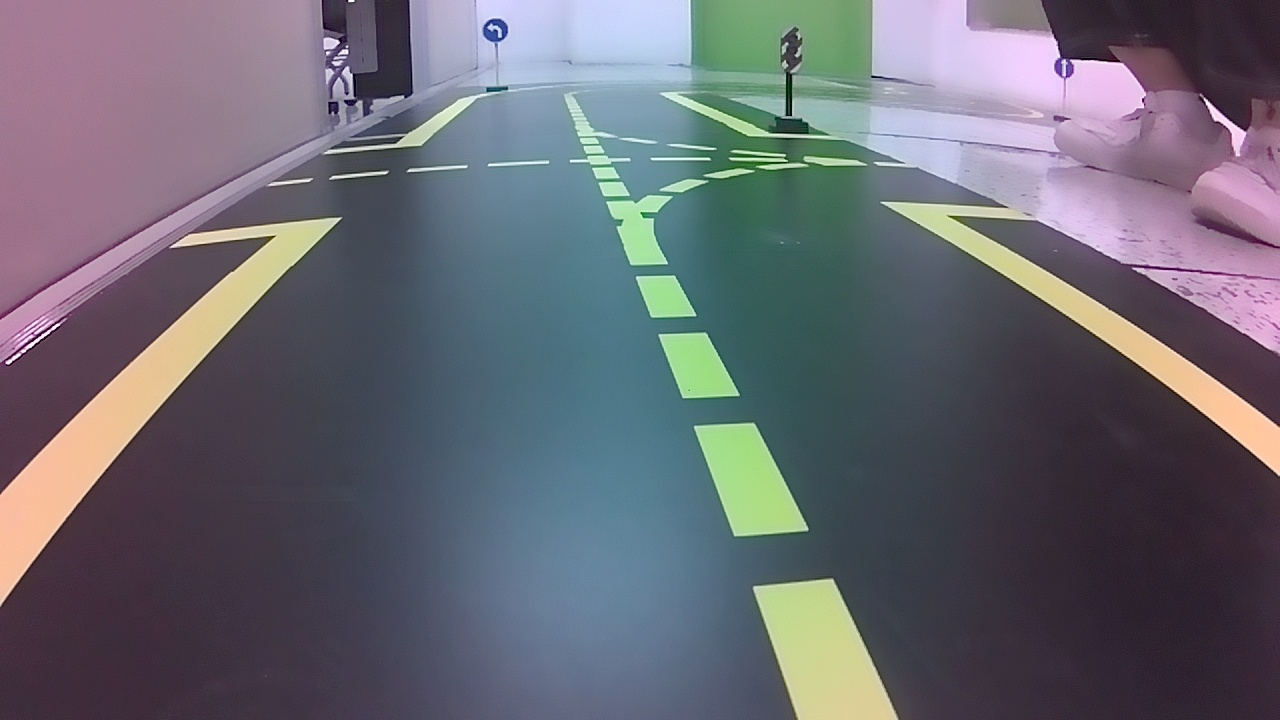

Exception in thread Thread-14 (view):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/ircv15/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_7158/2789743785.py", line 22, in view
  File "/home/ircv15/em7/perception/jetcam/camera.py", line 27, in read
    self.value = self._read()
  File "/home/ircv15/em7/perception/jetcam/csi_camera.py", line 62, in _read
    raise RuntimeError('Could not read image from camera')
RuntimeError: Could not read image from camera


In [ ]:
# Run
# ================
display(stopButton)
thread = threading.Thread(target=view, args=(stopButton,))
thread.start()

In [29]:
camera.release()